### Funkcje pomocnicze

In [ ]:
def radykal( f ) :
    """
    Funkcja zwraca radykał wielomianu podanego jako argument.
    """
    # pobieramy pierścień do którego należy f
    P = f.parent()
    # wyznaczamy radykał
    return P(f/gcd(f,f.derivative()))

def rozklad_bezkwadratowy( f ) :
    """
    Funkcja wyznacza rozkład bezkwadratowy wielomianu f, za pomocą algorytmu Guersenzvaiga-Szechtmana.
    """
    
    P = f.parent()
    x = P.0
    
    # współczynnik wiodący
    lcf = f.leading_coefficient()
    # normujemy f
    f = f.monic()
    # radykał
    r = radykal(f)
    s = r.degree()
    # wielomian pomocniczy p
    p = P( f.derivative()/gcd(f, f.derivative()) )
    # wielomian pomocniczy g
    _, g, h = xgcd(r.derivative(), r)
    # wielomian \mu
    # dla każdego pierwiastka \xi wielomianu f, 
    # \mu(\xi) = krotność \xi
    mu = (p*g).mod(r)
    
    # główna pętla
    k = 1
    n = 0
    G = []
    while n < f.degree() :
        # kolejny czynnik bezkwadratowy
        gk = gcd(mu - k, r)
        if not gk.is_constant() :
            G.append( (gk,k) )
            n += k*gk.degree()
        k += 1
        
    # zwracamy wynik
    return Factorization(G, unit = lcf, sort = false)

### Zadania/Exercises

In [ ]:
# Definiujemy pierścień wielomianów oraz wielomian f 
P.<x> = QQ[]
f = x^5 - 20*x^4 + 152*x^3 - 544*x^2 + 900*x - 529
show("f = " + latex(f))

f = x^{5} - 20 x^{4} + 152 x^{3} - 544 x^{2} + 900 x - 529

<p><span id="cell_outer_16"><span id="cell_outer_3"><strong>Zadanie:</strong> Napisać funkcję, która wyznacza oszacowanie górne modułów pierwiastków wielomianu na podstawie (pierwszego) twierdzenia Cauchy'ego.</span></span></p>

In [ ]:
def Cauchy_1( f ) :
    """
    Funkcja przyjmuje jako argument wielomian `f`, a w wyniku zwraca \
    taka liczbe `M`, ze wszystkie pierwiastki `f` naleza do przedzialu `(-M,M)`.
    Funkcja korzysta z twierdzenia Caychy'ego.
    """
    n = f.degree()
    return 1 + max([abs(f[j]/f[n]) for j in [0..n-1]])

In [ ]:
Cauchy_1(f)

901

<p><strong>Zadanie:</strong> Napisać funckję, która wyznacza postać ,,odprężoną'' (ang. <em>depressed</em>) podanego wielomianu $f$.</p>

In [ ]:
def depress( f ) :
    """
    Funkcja zwraca postac odprezona podanego wielomianu `f`
    """
    # wyznaczamy współczynnik wiodący
    lcf = f.leading_coefficient()
    # normujemy f
    f /= lcf
    # stopień f
    n = f.degree()
    # odprężamy f
    g = f( x-f[n-1]/n )
    return g

In [ ]:
depress(f)

x^5 - 8*x^3 + 4*x - 1

<p><span id="cell_outer_4"><span id="cell_outer_29"><strong>Zadanie:</strong> Napisać funkcję, która wyznacza oszacowanie górne modułów pierwiastków wielomianu używając drugiego twierdzenia Cauchy'ego. Które z tych dwóch twierdzeń daje lepsze oszacowanie dla wielomianu z poprzedniego przykładu?</span></span></p>

In [ ]:
def Cauchy_2( f ) :
    """
    Funkcja przyjmuje jako argument wielomian `f`, a w wyniku zwraca \
    taka liczbe `M`, ze wszystkie pierwiastki `f` naleza do przedzialu `(-M,M)`.
    Funkcja korzysta z twierdzenia Caychy'ego.
    """
    n = f.degree()
    return max( (n*abs(f[n-j]/f[n]))^(1/j) for j in [1..n] )

In [ ]:
Cauchy_2(f)

100

<p><strong>Zadanie:</strong> Zaimplementować oszacowanie Honga rzeczywistych pierwiastków wielomianu.</p>

In [ ]:
def Hong( f ) :
    """
    Funkcja przyjmuje jako argument wielomian `f`, a w wyniku zwraca \
    taka liczbe `M`, ze wszystkie RZECZYWISTE pierwiastki `f` są mniejsze od `M`.
    Funkcja korzysta z twierdzenia Honga.
    """
    if f.leading_coefficient() < 0 :
        f = -f
    n = f.degree()
    H = max( min( (-f[j]/f[i])^(1/(i-j)) for i in [j+1..n] if f[i] > 0 ) for j in [0..n-1] if f[j] < 0 )
    return 2*H

In [ ]:
Hong(f)

40

<p><strong>Zadanie:</strong> Zaimplementować algorytm local-max Vikglasa szacowania pierwiastków rzeczywistych wielomianu.</p>

In [ ]:
def local_max( f ) :
    """
    Funkcja przyjmuje jako argument wielomian `f`, a w wyniku zwraca \
    taka liczbe `M`, ze wszystkie RZECZYWISTE pierwiastki `f` są mniejsze od `M`.
    Funkcja korzysta z algorytmu local-max.
    """
    if f.leading_coefficient() < 0 :
        f = -f
    n = f.degree()
    M = 0
    t = 1
    i_max = n
    for j in [n-1,n-2,..0] :
        if f[j] > f[i_max] :
            i_max = j
            t = 1
        if f[j] < 0 :
            m = ( -2^t*f[j]/f[i_max] )^( 1/(i_max - j) )
            t = t+1
            M = max(m, M)
    return M

In [ ]:
local_max(f)

40

<p><strong>Zadanie:</strong> Napisać funkcję implementującą nierówność Laguerre-Samuelsona.</p>

In [ ]:
def Laguerre_Samuelson( f ) :
    """
    Funkcja przyjmuje jako argument wielomian `f`, a w wyniku zwraca \
    takie dwie liczby liczbe `M_-, M_+`, ze wszystkie RZECZYWISTE pierwiastki `f` \
    naleza do przedzialu `(M_-,M_+)`.
    Funkcja korzysta z twierdzenia Laguerre-Samuelsona.
    """
    assert f.degree() >= 2, "Stopien wielomianu musi wynisoc co najmniej 2"
    
    n = f.degree()
    a = -f[n-1]/(n*f[n])
    b = (n-1)/(n*f[n])*sqrt( f[n-1]^2 - 2*n/(n-1)*f[n]*f[n-2] )
    return (a-b, a+b)

In [ ]:
Mm, Mp = Laguerre_Samuelson(f)

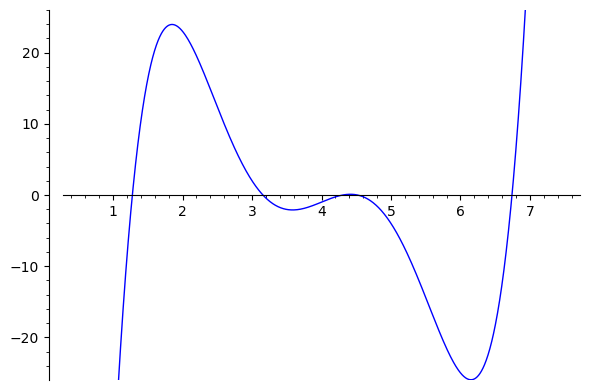

In [ ]:
# tworzymy wykres
f.plot(Mm, Mp, ymin = -25, ymax = 25)

<h1>Izolacja pierwiastków rzeczywistych</h1>


<b>Zadanie:</b> Napisać funkcję, która zlicza zmiany znaku w liście. Przetestować ją na listach $(1,3,-2,-4,5,17)$ oraz $(0,1,0,1,-1,0,0,-1,0,1,0,1)$.

In [ ]:
def zmiany_znaku( L ) :
    """
    Funkcja zlicza zmiany znaku na liscie `L`
    """
    # usuwamy z listy wszystkie wystąpienia zera, zaś elementy zastępujemy ich sygnaturami
    L = [ sgn(a) for a in L if a != 0 ]
    # pozostawiamy jedynie elementy mające znak różny od swojego poprzednika
    S = [ L[j] for j in range(1, len(L)) if L[j] != L[j-1] ]
    # ilość zmian znaku na wyjściowej liście L, to długość utworzonej listy S
    return len(S)

In [ ]:
zmiany_znaku( [1,3,-2,-4,5,17] )

2

In [ ]:
zmiany_znaku( [0,1,0,1,-1,0,0,-1,0,1,0,1] )

2

<strong>Zadanie:</strong> Zaimplementować algorytm Alesina'y-Galuzzi'ego. Wyizolować <span style="text-decoration: underline;">wszystkie</span> pierwiastki rzeczywiste wielomianu $f$ z poprzedniego zadania.

In [ ]:
def Alesina_Galuzzi( f, ab = (0,oo) ) :
    """
    Funkcja izoluje pierwiastki dodatnie podanego wielomianu f.
    
    DANE:
        
        - f wielomian
        
        - ab para liczb dodatnich, koncow przedzialu.
        
    """
    # wydzielamy końce przedziału
    a, b = ab[0], ab[1]
    # stopień wielomianu f
    n = f.degree()
    # pierścień z którego f pochodzi
    P = f.parent()
    # zmienna wielomianu
    x = P.0
    
    # w razie potrzeby zamieniamy b na ograniczenie górne (użyjemy local-max)
    if b == oo :
        b = local_max(f)
    # przypadek przedziału zdegenerowanego
    if a >= b :
        return []
        
    # wykonujemy podstawienie przekształcające (a,b) na (0,oo)
    g = P( (1+x)^f.degree() * f( (a+b*x)/(1+x) ) )
    # i liczymy zmiany znaku
    v = zmiany_znaku( g.list() )

    # albo nie ma pierwiastków...
    if v == 0 :
        return []
    # ...albo jest dokładnie jeden...
    if v == 1 :
        return [(a,b)]
    # ...albo nic nie wiemy i musimy połowić
    c = (a+b)/2
    L = Alesina_Galuzzi(f, (a,c))
    U = Alesina_Galuzzi(f, (c,b))
    
    # zwracamy wynik
    if f(c) == 0 :
        return L + [(c,c)] + U
    return L + U

In [ ]:
# izolujemy wszystkie pierwiastki
[ (-b,-a) for (a,b) in Alesina_Galuzzi(f(-x)) ][::-1] + Alesina_Galuzzi(f)

[(-4, -2), (-2, 0), (0, 1/2), (1/2, 1), (2, 4)]

<p><strong>Zadanie:</strong> Poprawić funkcję z poprzedniego zadania w tak sposób, aby zwracany ciąg nie tylko izolował pierwiastki $f$, ale aby w zwracanych przedziałach ani $f'$ ani $f''$ nie miały pierwiastów.</p>

In [ ]:
def Alesina_Galuzzi( f, ab = (0,oo) ) :
    """
    Funkcja izoluje pierwiastki dodatnie podanego wielomianu f, 
    omijajac jednoczesnie pierwiastki wielomianow f' oraz f''.
    
    DANE:
        
        - f wielomian
        
        - ab para liczb dodatnich, koncow przedzialu.
        
    """
    # wydzielamy końce przedziału
    a, b = ab[0], ab[1]
    # stopień wielomianu f
    n = f.degree()
    # pierścień z którego f pochodzi
    P = f.parent()
    # zmienna wielomianu
    x = P.0
    
    # w razie potrzeby zamieniamy b na ograniczenie górne (użyjemy local-max)
    if b == oo :
        b = local_max(f)
    # przypadek przedziału zdegenerowanego
    if a >= b :
        return []
        
    # wykonujemy podstawienie przekształcające (a,b) na (0,oo)
    g = P( (1+x)^f.degree() * f( (a+b*x)/(1+x) ) )
    # i liczymy zmiany znaku
    v = zmiany_znaku( g.list() )

    # albo nie ma pierwiastków...
    if v == 0 :
        return []
    # ...albo jest dokładnie jeden...
    if v == 1 :
        # to rozważamy pochodne 
        f_ = f.derivative()
        f__ = f.derivative(2)
        g_ = P( (1+x)^f_.degree() * f_( (a+b*x)/(1+x) ) )
        g__ = P( (1+x)^f__.degree() * f__( (a+b*x)/(1+x) ) )
        if zmiany_znaku(g_.list()) == 0 and zmiany_znaku(g__.list()) == 0 : 
            return [(a,b)]
    # ...albo nic nie wiemy i musimy połowić
    c = (a+b)/2
    L = Alesina_Galuzzi(f, (a,c))
    U = Alesina_Galuzzi(f, (c,b))
    
    # zwracamy wynik
    if f(c) == 0 :
        return L + [(c,c)] + U
    return L + U

In [ ]:
[ (-b,-a) for (a,b) in Alesina_Galuzzi(f(-x)) ][::-1] + Alesina_Galuzzi(f)

[(-3, -5/2), (-1, -1/2), (1/4, 3/8), (1/2, 1), (5/2, 3)]

<h1>Aproksymacja pierwiastków rzeczywistych wielomianu</h1>


<strong>Zadanie:</strong> Napisać funkcję, która aproksymuje pierwiastek wielomianu za pomocą bisekcji przedziału. Sprawdzić jej działanie dla wielomianu $f = x^2 - 2$.

In [ ]:
def bisekcja( f, ab, epsilon = 10^-10 ) :
    """
    Funkcja przybliża pierwiastek wielomianu f na przedziale (a,b) 
    z dokładnością epsilon, używając algorytmu bisekcji.
    """
    (a,b) = ab
    assert a < b, "Podano niewłaściwy przedział!"
    assert f(a)*f(b) < 0, "Wielomian musi mieć różne znaki na końcach przedziału!"
    
    while (b-a) > epsilon :
        c = (a+b)/2
        if f(a)*f(c) < 0 :
            b = c
        else :
            a = c
    return (a+b)/2

In [ ]:
R.<x> = QQ[]
f = x^2 - 2; show("f = " + latex(f))
xi = bisekcja(f, (0, 2.0))
show("\\xi = " + latex(xi) + ",\\quad f(\\xi) = " + latex(f(xi)) )

f = x^{2} - 2

\xi = 1.41421356235514 ,\quad f(\xi) = -5.07733854959724 \times 10^{-11}

<strong>Zadanie:</strong> Napisać funkcję, która przyjmuje jako argumenty: wielomian $f$ oraz przedział $(a,b)$ t.ż. $f$ ma przyjmuje przeciwne znaki na jego końcach. W wyniku działania funkcja zwraca jedną z trzech możliwości:

* pierwiastek $\xi\in (a,b)$ wielomianu $f$ jeżeli takowy został przypadkiem znaleziony;</li>
trójkę $(True, \alpha, \beta)$, gdzie $(\alpha, \beta)$ jest jedną z ćwiartek przedziału $(a,b)$ t.ż. $f$ zmienia znak na $(\alpha, \beta)$ oraz sieczna do $f$ na $(a,b)$ ma miejsce zerowe wewnątrz $(\alpha, \beta)$
* trójkę $(False, \alpha, \beta)$, gdzie $(\alpha, \beta)$ jest jedną z ćwiartek przedziału $(a,b)$ t.ż. $f$ zmienia znak na $(\alpha, \beta)$ oraz sieczna do $f$ na $(a,b)$ ma miejsce zerowe poza $(\alpha, \beta)$.


In [ ]:
def __QIR_4(f, ab) :
    """
    Podprocedura pomocnicza algorytmu QIR.
    
    Dane:
        
        - f wielomian, którego pierwiastka szukamy,
        
        - ab = (a,b) przedział na końcach, którego f przyjmuje przeciwne znaki.
        
    Wynikiem działania funkcji jest jedna z trzech wartości:
        
        - xi in (a,b) dokładny, znaleziony pierwiastek wielomianu f;
        
        - trójka (True, alpha, beta) taka, że f posiada pierwiastek xi in (alpha, beta), 
        długość przedziału (alpha, beta) wynosi 1/4 długości przedziału (a,b) oraz sieczna do 
        wykresu f na przedziale (a,b) przecina oś OX wewnątrz (alpha, beta);
        
        - trójka (False, alpha, beta) taka, że f posiada pierwiastek xi in (alpha, beta), 
        długość przedziału (alpha, beta) wynosi 1/4 długości przedziału (a,b) oraz sieczna do 
        wykresu f na przedziale (a,b) przecina oś OX POZA przedziałem (alpha, beta).
        
    """
    (a,b) = ab
    
    # ćwiartka zawierająca miejsce zerowe siecznej
    k = floor( 4*f(a)/ (f(a) - f(b)) )
    ak = a + (b-a)/4*k
    # dwukrtona bisekcja
    c = (a+b)/2
    if f(c) == 0 :
        return c
    (a,b) = (a,c) if f(a)*f(c) < 0 else (c,b)
    c = (a+b)/2
    if f(c) == 0 :
        return c
    (a,b) = (a,c) if f(a)*f(c) < 0 else (c,b)
    # zwracamy wynik
    return (ak == a, a, b)

In [ ]:
__QIR_4(f, (0,3))

(False, 3/4, 3/2)

<strong>Zadanie:</strong> Napisać funkcję, która przyjmuje jako argumenty:

* wielomian $f$
* przedział $(a,b)$ t.ż. $f$ ma różne znaki na jego końcach
* potęgę dwójki $N$ 

zaś w wyniku zwraca jedną z trzech możliwości:
* pierwiastek $\xi\in (a,b)$ wielomianu $f$ (jeśli przez przypadek został wyznaczony);
* parę $(\alpha, \beta)$ stanowiącą końce $1/N$-tej przedziału $(a,b)$ jeśli $f$ zmienia znak na $(\alpha, \beta)$ <span style="text-decoration: underline;">oraz równocześnie</span> sieczna do wykresu $f$ na $(a,b)$ ma miejsce zerowe wewnątrz $(\alpha, \beta)$;
* stałą logiczną <span style="font-family: courier new,courier;">False</span> w przeciwnym przypadku.


In [ ]:
def __QIR_N(f, ab, N) :
    """
    Podprocedura pomocnicza algorytmu QIR.
    
    Dane:
        
        - f wielomian, którego pierwiastka szukamy,
        
        - ab = (a,b) przedział na końcach, którego f przyjmuje przeciwne znaki,
        
        - N > 4 potęga dwójki określająca na ile podprzedziałów podzielić (a,b)
        
    Wynikiem działania funkcji jest jedna z trzech wartości:
        
        - xi in (a,b) dokładny, znaleziony pierwiastek wielomianu f;
        
        - para (alpha, beta) taka, że f posiada pierwiastek xi in (alpha, beta), 
        długość przedziału (alpha, beta) wynosi 1/N długości przedziału (a,b) oraz sieczna do 
        wykresu f na przedziale (a,b) przecina oś OX wewnątrz (alpha, beta);
        
        - False jezeli f ma równe znaki na końcach przedziału o długości 1/N zawierającego 
        miejsce zerowe siecznej do wykresu f na (a,b).
        
    """
    (a,b) = ab
    
    k = floor( N*f(a)/( f(a) - f(b) ) )
    delta = (b-a)/N
    ak = a + delta*k
    if f(ak) == 0 :
        return a
    if f(ak+delta) == 0 :
        return ak+delta
    if f(ak)*f(ak+delta) < 0 :
        return (ak, ak+delta)
    return False

<strong>Zadanie:</strong> Zaimplementować algorytm QIR aproskymacji pierwiastka wielomianu $f$ na podanym przedziale.

In [ ]:
def QIR( f, ab, epsilon = 10^-10 ) :
    """
    Funkcja znajduje pierwiastek wielomianu f na przedziale ab = (a,b) z przybliżeniem
    epsilon za pomocą algorytmu QIR.
    
    Dane:
        
        - f wielomian;
        
        - ab = (a,b) przedział na koncach którego f ma rożne znaki;
        
        - epsilon zadane przybliżenie (dommyślnie epsilon = 10^(-10).
    """
    (a,b) = ab
    assert a < b, "Podano przedział niewłaściwy!"
    assert f(a)*f(b) < 0, "Wielomian musi mieć różne znaki na końcach przedziału!"
    
    # inicjalizacja 
    N = 4
    # główna pętla
    while b - a > epsilon :
        # przypadek graniczny
        if N == 4 :
            r = __QIR_4(f, (a, b))
            # czy r jest liczbą?
            if r in RR :
                # jeżeli tak to mamy pierwiastek
                return r
            # r musi być trójką
            if r[0] :
                N = 16
            a, b = r[1], r[2]
        # przypadek bazowy (N > 4)
        else :
            r = __QIR_N(f, (a, b), N)
            # czy spudłowaliśmy
            if r == False :
                N = max(isqrt(N), 4)
                continue
            # czy r jest liczbą?
            if r in RR :
                # jeżeli tak to mamy pierwiastek
                return r
            # r musi być parą
            else :
                a, b = r[0], r[1]
                N = N^2
    return (a+b)/2

In [ ]:
xi = QIR( f, (0,3), 10^-100 )
print( f(xi).n() )

-1.31352881257360e-173


<span id="cell_outer_29"><strong>Zadanie:</strong> Napisać funkcję wyznaczającą pierwiastki rzeczywiste wielomianu jednej zmiennej.</span>

In [ ]:
def rozklad_bezkwadratowy( f ) :
    """
    Funkcja wyznacza rozkład bezkwadratowy wielomianu f, za pomocą algorytmu Guersenzvaiga-Szechtmana.
    """
    
    P = f.parent()
    x = P.0
    
    # współczynnik wiodący
    lcf = f.leading_coefficient()
    # normujemy f
    f = f.monic()
    # radykał
    r = radykal(f)
    s = r.degree()
    # wielomian pomocniczy p
    p = P( f.derivative()/gcd(f, f.derivative()) )
    # wielomian pomocniczy g
    _, g, h = xgcd(r.derivative(), r)
    # wielomian \mu
    # dla każdego pierwiastka \xi wielomianu f, 
    # \mu(\xi) = krotność \xi
    mu = (p*g).mod(r)
    
    # główna pętla
    k = 1
    n = 0
    G = []
    while n < f.degree() :
        # kolejny czynnik bezkwadratowy
        gk = gcd(mu - k, r)
        if not gk.is_constant() :
            G.append( (gk,k) )
            n += k*gk.degree()
        k += 1
        
    # zwracamy wynik
    return Factorization(G, unit = lcf, sort = false)

In [ ]:
def pierwiastki_rzeczywiste( f, epsilon = 10^-3 ) :
    """
    Funkcja wyznacza wszystkie rzeczywiste pierwiastki 
    wielomianu f z zadanym przybliżeniem epsilon.
    """
    # pierścień, do którego należy f
    P = f.parent()
    # zmienna wielomianu f
    x = P.0
    
    # znajdujemy rozkład bezkwadratowy f
    G = rozklad_bezkwadratowy(f)
    X = []
    # dla każdego dzielnika bezkwadratowego
    for (g,k) in G :
        # pomijamy wyrazy stałe
        if g in f.base_ring() :
            continue
        
        # wyznaczamy przedziały separujące pierwiastki
        A = Alesina_Galuzzi(g)
        B = Alesina_Galuzzi(g(-x))
        W = [ (-b,-a) for (a,b) in B[::-1] ] + A
        # w każdym przedziale
        for (a,b) in W :
            if a < b :
                # aproksymujemy pierwiastek 
                xi = QIR(g, (a,b), epsilon)
                # i dołączamy do listy wraz z krotnością 
                # (równą krotności dzielnika bezkwadratowego)
                X.append((xi,k))
            else :
                # szczególny przypadek gdy a=b jest dokładnym pierwiastkiem
                X.append((a,k))
                
    return X

In [ ]:
# sprawdzamy na przykładzie
P.<x> = QQ[]
pierwiastki_rzeczywiste( x^5-5*x^3+4*x-1 )

[(-16007/8192, 1),
 (-2357/2048, 1),
 (1129/4096, 1),
 (1619/2048, 1),
 (133595/65536, 1)]